# LST 이상치 확인

데이터 로드 후 LST_C 분포를 히스토그램·박스플롯으로 확인.

In [6]:
# =========================
# Global Configuration
# =========================

RAW_LST_DIR = "../data_processed/processed/lst"
OUTPUT_DIR = "../data_processed/processed/lst"
YEAR = 2025

In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [8]:
# =========================
# LST 로드
# =========================

def load_lst(year, lst_dir=RAW_LST_DIR):
    for name in [
        f"lst_{year}.csv",
        f"lst_{year}_summer_100m.csv",
    ]:
        path = os.path.join(lst_dir, name)
        if os.path.isfile(path):
            df = pd.read_csv(path)
            if {"cell_id", "LST_C"}.issubset(df.columns):
                return df
    raise FileNotFoundError(f"LST 파일 없음: {lst_dir}")

df = load_lst(YEAR)
print("Rows:", len(df))

Rows: 92398


In [9]:
df.describe()

,LST_C,cell_id
count,91766.000000,9.239800e+04
mean,35.701170,1.413823e+12
std,4.840435,9.913904e+08
min,16.368220,1.411415e+12
25%,32.480820,1.413085e+12
50%,36.715693,1.413915e+12
75%,39.286044,1.414605e+12
max,50.821862,1.415945e+12


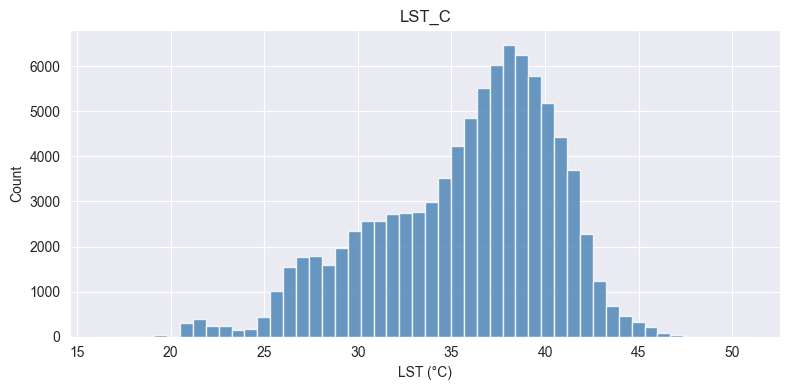

In [10]:
# Histogram
plt.figure(figsize=(8, 4))
plt.hist(df["LST_C"].dropna(), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.xlabel("LST (°C)")
plt.ylabel("Count")
plt.title("LST_C")
plt.tight_layout()
plt.show()

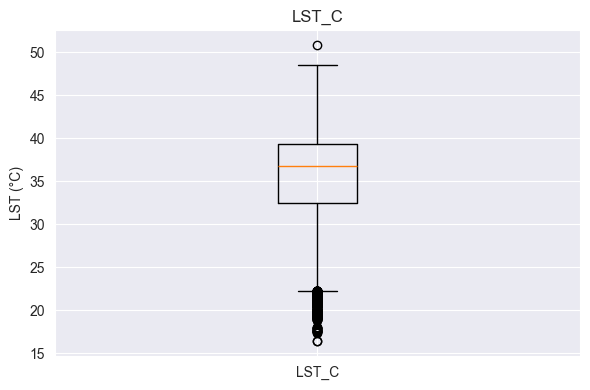

In [12]:
# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df["LST_C"].dropna(), tick_labels=["LST_C"])
plt.ylabel("LST (°C)")
plt.title("LST_C")
plt.tight_layout()
plt.show()

In [13]:
Q1 = df['LST_C'].quantile(0.25)
Q3 = df['LST_C'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df_clean = df[df['LST_C'] <= upper_bound]

print("Upper bound:", upper_bound)
print("제거된 개수:", (df['LST_C'] > upper_bound).sum())


Upper bound: 49.49388058091933
제거된 개수: 1


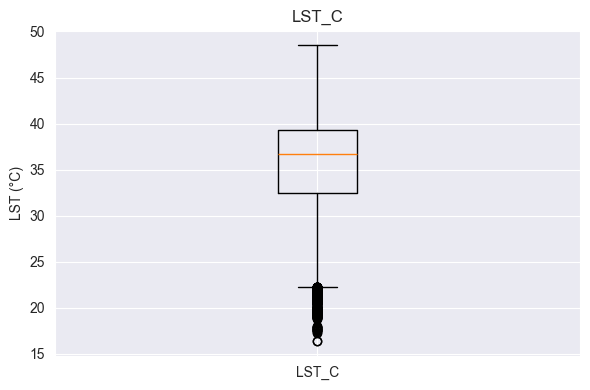

In [14]:
# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df_clean["LST_C"].dropna(), tick_labels=["LST_C"])
plt.ylabel("LST (°C)")
plt.title("LST_C")
plt.tight_layout()
plt.show()

In [15]:
# df_clean을 data_processed/processed/lst에 저장 (전처리된 데이터)
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_name = f"lst_{YEAR}_summer_100m_clean.csv"
out_path = os.path.join(OUTPUT_DIR, out_name)
df_clean[["cell_id", "LST_C"]].to_csv(out_path, index=False, encoding="utf-8-sig")
print("Saved:", out_path)

Saved: ../data_processed/processed/lst/lst_2025_summer_100m_clean.csv
